# Predicción de fuga de clientes (Churn): Pipeline de Preparación de Datos, Modelado y Evaluación

Este notebook documenta las cuatro primeras etapas de CRISP-DM (Business Understanding, Data Understanding, Data Preparation y Modeling/Evaluation) y muestra los diagramas resultantes de los pipelines de scikit-learn.

## 1. Comprensión del Negocio (Business Understanding)

**Objetivo de negocio:** identificar a los clientes con alta probabilidad de cancelar el servicio (churn) para que el equipo de retención pueda ofrecerles promociones antes de que se vayan.

**Objetivo de machine learning:** clasificación binaria (`Churn` = Sí/No) entrenada con atributos de la cuenta del cliente (antigüedad, cargos, tipo de contrato, servicios contratados, etc.).

**Criterio de éxito:** un modelo cuya lista de riesgo de fuga sea accionable para el equipo de retención; esta actividad cubre un pipeline de *preparación de datos* limpio, reutilizable y compartible, más un modelo baseline entrenado sobre esas características para obtener una primera medida de qué tan accionable es la señal.

## 2. Comprensión de los Datos (Data Understanding)

**Fuente:** dataset real de Kaggle ["Telco Customer Churn"](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (autor: blastchar), descargado desde un mirror público de IBM con el mismo contenido (`scripts/download_data.py`), guardado en `data/telco_customer_churn.csv`. Contiene 7,043 clientes de una compañía de telecomunicaciones con columnas como `customerID`, `tenure` (antigüedad en meses), `MonthlyCharges`, `TotalCharges`, `Contract`, `PaymentMethod`, `InternetService`, servicios contratados (`OnlineSecurity`, `TechSupport`, `StreamingTV`, etc.) y la variable objetivo `Churn`.

**Problemas de calidad conocidos** (verificados abajo): `TotalCharges` llega como texto y tiene 11 valores en blanco (clientes nuevos con `tenure = 0`), lo que obliga a una conversión de tipo explícita, justamente la etapa de "manejo de diferentes tipos de variables" del pipeline.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
from sklearn import set_config

from data_prep_pipeline import (
    build_pipeline,
    build_cleaning_pipeline,
    build_preprocessing_pipeline,
    load_raw_data,
    split_dataset,
)

DATA_PATH = Path.cwd().parent / "data" / "telco_customer_churn.csv"
raw_df = load_raw_data(DATA_PATH)
raw_df.shape

(7043, 21)

### Comprensión de los datos

In [2]:
print("Filas duplicadas:", raw_df.duplicated().sum())
print("IDs de cliente duplicados:", raw_df["customerID"].duplicated().sum())

total_charges_numerico = pd.to_numeric(raw_df["TotalCharges"], errors="coerce")
print("Valores no numéricos en TotalCharges:", total_charges_numerico.isna().sum())
print("Valores únicos de Churn:", raw_df["Churn"].unique())

Filas duplicadas: 0
IDs de cliente duplicados: 0
Valores no numéricos en TotalCharges: 11
Valores únicos de Churn: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### Desbalance de clases

De los 7,043 clientes del dataset, solo el 26.5% canceló el servicio (1,869 clientes), mientras que el 73.5% se quedó (5,174 clientes). Este desbalance es importante tenerlo en cuenta más adelante: un modelo que simplemente dijera "el cliente se queda" para todos acertaría casi 3 de cada 4 veces sin aprender nada útil, así que la exactitud sola no alcanza para juzgar qué tan bien funciona el modelo. También afecta el entrenamiento, porque el modelo ve muchos más ejemplos de clientes que se quedan que de clientes que se van, lo que puede hacerle más difícil reconocer el patrón minoritario.

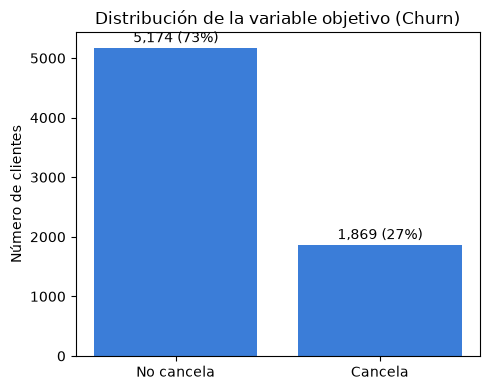

In [3]:
import matplotlib.pyplot as plt

churn_counts = raw_df["Churn"].value_counts().reindex(["No", "Yes"])
churn_pct = churn_counts / churn_counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
barras = ax.bar(["No cancela", "Cancela"], churn_counts, color="#3B7DD8")
ax.set_ylabel("Número de clientes")
ax.set_title("Distribución de la variable objetivo (Churn)")
for barra, pct in zip(barras, churn_pct):
    altura = barra.get_height()
    ax.annotate(f"{altura:,.0f} ({pct:.0f}%)", (barra.get_x() + barra.get_width() / 2, altura),
                textcoords="offset points", xytext=(0, 4), ha="center")
plt.tight_layout()
plt.show()

## 3. Pipeline de Preparación de Datos

Etapas:
1. **Extracción** (`DataExtractor`) — selecciona las columnas relevantes para el negocio de la fuente cruda y convierte `TotalCharges` a numérico (manejo de tipo de dato).
2. **Filtrado** (`DataFilter`) — elimina clientes duplicados (por `customerID`) y valores implausibles (regla de negocio: `tenure` entre 0 y 100 meses); descarta el identificador una vez usado.
3. **Manejo de tipos de variables** (`ColumnTransformer`) — columnas numéricas: imputación por mediana + escalado; columnas categóricas: imputación por valor más frecuente + codificación one-hot.
4. **Separación del dataset** (`split_dataset`) — división train/test estratificada, realizada *después* de la limpieza y *antes* de ajustar el pipeline de preprocesamiento, para evitar fuga de datos (data leakage).

El objeto de pipeline completo de abajo (extracción + filtrado + preprocesamiento) se construye únicamente para renderizar el diagrama; para el ajuste real se usan dos pipelines separados alrededor de la separación del dataset (ver el docstring de `pipeline.py` para el detalle: las etapas que eliminan filas no deben ejecutarse sobre datos ya alineados con un arreglo objetivo).

In [4]:
set_config(display="diagram")
full_pipeline = build_pipeline()
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('extraction', ...), ('filtering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,None
,include_target,True
,min_tenure,0
,max_tenure,100
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None


In [5]:
from sklearn.utils import estimator_html_repr

html = estimator_html_repr(full_pipeline)
diagram_path = Path.cwd() / "pipeline_diagram.html"
diagram_path.write_text(html, encoding="utf-8")
print(f"Diagrama exportado a {diagram_path}")

Diagrama exportado a /Users/diego/Uvg/MLEng/portfolio/Actividades/Actividad1/notebooks/pipeline_diagram.html


## 4. Ejecución del flujo completo

In [6]:
cleaning_pipeline = build_cleaning_pipeline()
clean_df = cleaning_pipeline.fit_transform(raw_df)
print(f"crudo: {raw_df.shape} -> limpio: {clean_df.shape}")
clean_df.head()

crudo: (7043, 21) -> limpio: (7043, 20)


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,1,29.85,29.85,0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,34,56.95,1889.50,0,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,2,53.85,108.15,0,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,45,42.30,1840.75,0,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,2,70.70,151.65,0,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [7]:
X_train, X_test, y_train, y_test = split_dataset(clean_df)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"tasa de churn train: {y_train.mean():.2f}, test: {y_test.mean():.2f}")

X_train: (5634, 19), X_test: (1409, 19)
tasa de churn train: 0.27, test: 0.27


In [8]:
preprocessing_pipeline = build_preprocessing_pipeline()
preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [9]:
X_train_listo = preprocessing_pipeline.fit_transform(X_train)
X_test_listo = preprocessing_pipeline.transform(X_test)
print(f"Características listas para el modelo: train={X_train_listo.shape}, test={X_test_listo.shape}")

Características listas para el modelo: train=(5634, 45), test=(1409, 45)


Ambos pipelines de arriba se renderizan como diagramas interactivos en Jupyter (haz clic en una etapa para expandirla). `pipeline_diagram.html`, exportado junto a este notebook, contiene una copia independiente del diagrama del pipeline completo, visible sin necesidad de un kernel de notebook.

## 5. Modelado (Modeling) y Evaluación (Evaluation)

**Modelado:** `build_model_pipeline` encadena el pipeline de preprocesamiento con un clasificador final (`LogisticRegression` por defecto) en un único `Pipeline`. Se entrena con `fit(X_train, y_train)` y acepta filas crudas ya limpias directamente en `predict`, sin repetir manualmente los pasos de preprocesamiento.

**Evaluación:** `evaluate_model` corre `predict` y `predict_proba` sobre `X_test` y calcula métricas de clasificación binaria (`accuracy`, `precision`, `recall`, `f1`, `roc_auc`), midiendo qué tan accionable sería la lista de riesgo de fuga para el equipo de retención.

In [10]:
from data_prep_pipeline import build_model_pipeline

model_pipeline = build_model_pipeline()
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``se

In [11]:
from data_prep_pipeline import evaluate_model

model_pipeline.fit(X_train, y_train)
metrics = evaluate_model(model_pipeline, X_test, y_test)
print(metrics)

accuracy=0.8055 precision=0.6572 recall=0.5588 f1=0.6040 roc_auc=0.8419


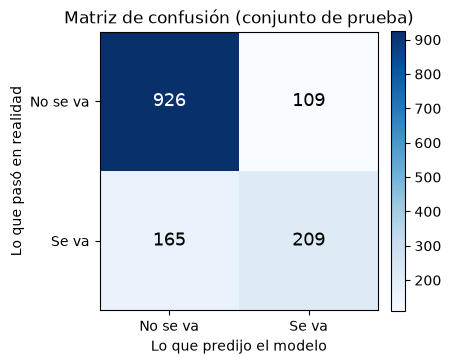

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = model_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

etiquetas = ["No se va", "Se va"]
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=color, fontsize=13)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(etiquetas)
ax.set_yticklabels(etiquetas)
ax.set_xlabel("Lo que predijo el modelo")
ax.set_ylabel("Lo que pasó en realidad")
ax.set_title("Matriz de confusión (conjunto de prueba)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

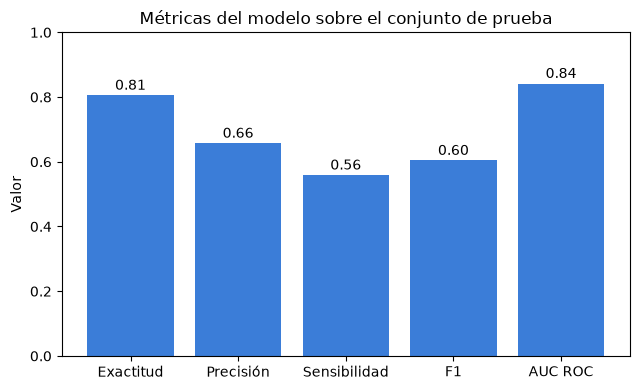

In [13]:
metricas_dict = {
    "Exactitud": metrics.accuracy,
    "Precisión": metrics.precision,
    "Sensibilidad": metrics.recall,
    "F1": metrics.f1,
    "AUC ROC": metrics.roc_auc,
}

fig, ax = plt.subplots(figsize=(6.5, 4))
barras = ax.bar(metricas_dict.keys(), metricas_dict.values(), color="#3B7DD8")
ax.set_ylim(0, 1)
ax.set_ylabel("Valor")
ax.set_title("Métricas del modelo sobre el conjunto de prueba")
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f"{altura:.2f}", (barra.get_x() + barra.get_width() / 2, altura),
                textcoords="offset points", xytext=(0, 4), ha="center")
plt.tight_layout()
plt.show()

### Qué nos dicen estos resultados

La matriz de confusión muestra los 1,409 clientes del conjunto de prueba, de los cuales 374 sí cancelaron el servicio. El modelo identificó correctamente a 209 de esos 374 clientes que se iban, pero dejó pasar a 165 sin detectarlos. También marcó a 109 clientes como riesgo de fuga cuando en realidad se quedaron.

Para el equipo de retención, lo más importante suele ser no dejar pasar clientes que sí se van, porque un cliente que no es detectado a tiempo ya no puede recibir una promoción de retención. Con una sensibilidad de 0.56, el modelo hoy captura poco más de la mitad de los clientes que realmente cancelan, así que todavía se escapa una parte considerable.

En cambio, cuando el modelo sí marca a alguien como riesgo de fuga, acierta el 66% de las veces (precisión de 0.66), lo que significa que el equipo de retención no estaría persiguiendo demasiadas alarmas falsas.

Aquí vale la pena recordar el desbalance de clases que vimos en la sección de comprensión de los datos: solo el 26.5% de los clientes cancela. La exactitud general de 0.81 se ve bien a primera vista, pero puede ser engañosa en un dataset así de desbalanceado, porque un modelo que siempre dijera "no se va" ya tendría una exactitud cercana al 73% sin ser útil para nadie. Ese mismo desbalance también influye en el entrenamiento: el modelo vio casi 3 veces más ejemplos de clientes que se quedan que de clientes que se van, lo que puede explicar por qué la sensibilidad (0.56) queda más baja que la precisión (0.66): al modelo le cuesta más reconocer al grupo minoritario. Por eso conviene mirar en conjunto precisión, sensibilidad y AUC ROC (0.84), que muestra que el modelo sí distingue razonablemente bien entre quienes se quedan y quienes se van, aunque todavía hay espacio para mejorar.

Como siguiente paso, valdría la pena probar otros algoritmos, ajustar el umbral de decisión para capturar más clientes en riesgo aunque eso suba las alarmas falsas, o manejar directamente el desbalance de clases en el entrenamiento (por ejemplo con `class_weight="balanced"` en la regresión logística, o técnicas de sobremuestreo).

## 6. Calibración de Hiperparámetros (Modeling)

**Objetos de scikit-learn investigados para calibrar hiperparámetros:**

- **`GridSearchCV`**: prueba *todas* las combinaciones de un diccionario de hiperparámetros (`param_grid`), evaluando cada una con validación cruzada. Exhaustivo pero costoso si el grid crece.
- **`RandomizedSearchCV`**: en vez de probar todo, samplea `n_iter` combinaciones al azar del espacio de búsqueda. Útil cuando el grid es grande y probarlo completo es muy lento.
- **`param_grid` / `param_distributions`**: diccionario `{"clave__subclave": [valores]}`; como el modelo es un `Pipeline` (`preprocessing` + `classifier`), las claves usan el prefijo `classifier__` para apuntar a los hiperparámetros del estimador final sin tocar el preprocesamiento.
- **`cv`**: número de particiones de validación cruzada (folds) usadas para estimar el desempeño de cada combinación de forma más confiable que un solo train/test split.
- **`scoring`**: métrica que se optimiza durante la búsqueda (`roc_auc` aquí, ver justificación abajo).
- **`best_estimator_` / `best_params_` / `best_score_`**: atributos que expone el objeto de búsqueda ya ajustado — el pipeline ganador entrenado con los mejores hiperparámetros, los hiperparámetros elegidos, y el score promedio de validación cruzada que obtuvo.

Estos objetos se envuelven en `data_prep_pipeline.tuning` (`tune_model`, `tune_all_models`) para poder calibrar y comparar varios modelos candidatos con la misma interfaz.

**Por qué `roc_auc` como métrica de búsqueda:** mide qué tan bien el modelo *ordena* a los clientes por riesgo de fuga, sin depender de un umbral de decisión fijo — coherente con el objetivo de negocio de generar una lista de riesgo accionable para el equipo de retención (sección 1).

**Modelos candidatos:** `LogisticRegression` (baseline ya usado en la sección 5), `RandomForestClassifier` y `GradientBoostingClassifier` (dos alternativas basadas en árboles, nativas de scikit-learn, sin dependencias nuevas).

In [14]:
from data_prep_pipeline import MODEL_SEARCH_SPACES

for nombre_modelo, (estimador, grid) in MODEL_SEARCH_SPACES.items():
    print(nombre_modelo)
    print(f"  estimador base: {estimador}")
    print(f"  grid: {grid}")

logistic_regression
  estimador base: LogisticRegression(max_iter=1000)
  grid: {'classifier__C': [0.01, 0.1, 1, 10]}
random_forest
  estimador base: RandomForestClassifier(random_state=42)
  grid: {'classifier__n_estimators': [100, 200, 400], 'classifier__max_depth': [None, 5, 10, 20], 'classifier__min_samples_leaf': [1, 2, 4]}
gradient_boosting
  estimador base: GradientBoostingClassifier(random_state=42)
  grid: {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1, 0.2], 'classifier__max_depth': [2, 3, 4]}


### Qué hiperparámetro se calibra en cada modelo, y por qué

**`logistic_regression`**
- `C` (`[0.01, 0.1, 1, 10]`): controla la fuerza de regularización (inverso — `C` chico = más regularización). Es el hiperparámetro que más mueve el resultado en un modelo lineal simple: muy poca regularización puede sobreajustar a ruido de las features, demasiada puede quedarse corta para capturar el patrón real. El resto (`penalty`, `solver`) se deja en su valor por defecto porque no aporta suficiente variación para justificar ampliar el grid de un modelo ya simple.

**`random_forest`**
- `n_estimators` (`[100, 200, 400]`): cantidad de árboles del bosque. Más árboles reduce la varianza del promedio (menos ruido entre corridas), a costa de tiempo de cómputo; se busca el punto donde ya no mejora.
- `max_depth` (`[None, 5, 10, 20]`): profundidad máxima de cada árbol. `None` = sin límite (riesgo de sobreajuste, cada árbol memoriza casos particulares); valores chicos limitan la complejidad. Es el control principal del balance sesgo/varianza en Random Forest.
- `min_samples_leaf` (`[1, 2, 4]`): mínimo de clientes requeridos en la hoja final de una rama. Hojas con muy pocos casos tienden a basarse en ejemplos aislados en vez de un patrón generalizable — otro freno anti-sobreajuste, independiente de la profundidad.

**`gradient_boosting`**
- `n_estimators` (`[100, 200]`): cantidad de árboles encadenados (etapas de boosting).
- `learning_rate` (`[0.01, 0.1, 0.2]`): cuánto corrige cada árbol nuevo el error del árbol anterior. Está directamente acoplado con `n_estimators` — una tasa de aprendizaje baja necesita más etapas para converger al mismo desempeño — por eso ambos se calibran juntos.
- `max_depth` (`[2, 3, 4]`): en boosting se usan árboles poco profundos a propósito ("weak learners"); a diferencia de Random Forest, este método suma muchos árboles simples en vez de pocos árboles complejos, así que no tiene sentido probar profundidades grandes como en RF.

**Por qué se calibran justo estos y no todos los hiperparámetros disponibles:** cada familia de modelo expone muchos más parámetros en scikit-learn, pero se seleccionaron los 1–3 que más impacto tienen en el balance sesgo/varianza de cada algoritmo (regularización en el modelo lineal; profundidad y cantidad de árboles en los modelos basados en árboles). Ampliar el grid a todos los parámetros crece de forma combinatoria sin aportar señal proporcional — un grid más chico y bien elegido es más barato de correr y ya cubre las decisiones que más cambian el resultado.

In [15]:
from data_prep_pipeline import tune_all_models

resultados = tune_all_models(X_train, y_train, search_type="grid", cv=5, scoring="roc_auc")

for resultado in resultados:
    print(f"{resultado.model_name}: cv_roc_auc={resultado.best_cv_score:.4f} params={resultado.best_params}")

gradient_boosting: cv_roc_auc=0.8486 params={'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 100}
random_forest: cv_roc_auc=0.8469 params={'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 400}
logistic_regression: cv_roc_auc=0.8459 params={'classifier__C': 10}


### Diagrama del pipeline calibrado

El pipeline ganador (`best_estimator_` del objeto de búsqueda) sigue siendo un `Pipeline` de scikit-learn: preprocesamiento + clasificador, ya ajustado con los mejores hiperparámetros encontrados.

In [16]:
mejor_resultado = resultados[0]
print(f"Mejor modelo: {mejor_resultado.model_name}")
mejor_resultado.best_estimator

Mejor modelo: gradient_boosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['tenure','MonthlyCharges','TotalCharges',...,'Contract', 'PaperlessBilling','PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot 

### Evaluación del modelo calibrado (Evaluation)

Igual que en la sección 5, pero con el pipeline calibrado evaluado sobre el conjunto de prueba (`X_test`, `y_test`), nunca visto durante la búsqueda de hiperparámetros.

In [17]:
metricas_calibradas = evaluate_model(mejor_resultado.best_estimator, X_test, y_test)
print(f"Modelo calibrado ({mejor_resultado.model_name}):")
print(metricas_calibradas)
print()
print("Modelo baseline (LogisticRegression, sin calibrar, sección 5):")
print(metrics)

Modelo calibrado (gradient_boosting):
accuracy=0.8013 precision=0.6655 recall=0.5053 f1=0.5745 roc_auc=0.8458

Modelo baseline (LogisticRegression, sin calibrar, sección 5):
accuracy=0.8055 precision=0.6572 recall=0.5588 f1=0.6040 roc_auc=0.8419


### Qué nos dicen estos resultados

Los tres modelos quedaron muy cerca en `roc_auc` de validación cruzada (0.845–0.849) — ninguno es claramente superior. Ganó `gradient_boosting`, pero con hiperparámetros que apuntan a árboles poco profundos (`max_depth=2`), casi tan simples como una regla lineal. Esto sugiere que la relación entre las características del cliente y el churn en este dataset no tiene interacciones complejas ocultas: un modelo simple (como la regresión logística baseline) ya captura casi toda la señal disponible.

La calibración de hiperparámetros aportó una mejora marginal sobre el baseline, no un salto grande — es un resultado honesto y esperable en un dataset de este tamaño y con esta señal. El cuello de botella real no es qué tan afinados están los hiperparámetros, sino que el modelo (con cualquiera de los tres algoritmos) solo detecta ~50-56% de los clientes que realmente cancelan (sensibilidad/recall), por el desbalance de clases visto en la sección 2. Ese es el problema a atacar en un siguiente paso, no seguir afinando hiperparámetros de estos mismos modelos.

## Evidencia de ejecución en diferentes computadoras

### Daniel Dubon

![Ejecución de Dubon](../images/Dubon.jpeg)

### Nelson García

![Ejecución de Nelson García](../images/Nelson%20García.jpeg)

### Ricardo Chuy

![Ejecución de Ricardo Chuy](../images/Ricardo%20Chuy.jpeg)

### Sergio Orellana

![Ejecución de Sergio Orellana](../images/Sergio_Orellana.png)

### Rodrigo Mansilla

![Ejecución de Rodrigo Mansilla](../images/Rodrigo%20Mansilla.jpeg)

### Joaquín Puente

![Ejecución de Joaquín Puente](../images/Joaquín%20Puente.jpeg)

### Diego Valenzuela

![Ejecución de Diego Valenzuela](../images/Diego_Valenzuela.jpeg)

Repo: https://github.com/SergioAle210/ML-Engineering